In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit

In [2]:
path = Path.cwd().joinpath("Voltages.csv")
csv = pd.read_csv(path)

print(csv.head())

   Voltage  Resistance   Current  Reading 1  Reading 2
0     26.7        47.0  0.568085        132        188
1     26.7        41.3  0.646489        138        219
2     26.7        31.3  0.853035        199        270
3     26.7        22.5  1.186667        291        385
4     26.7        18.8  1.420213        360        411


In [3]:
reading_1_offset = -20
reading_2_offset = 57
csv["Voltage 1"] = (csv["Reading 1"] - reading_1_offset) * 0.0001875
csv["Voltage 2"] = (csv["Reading 2"] - reading_2_offset) * 0.0001875
csv.head(20)

,Voltage,Resistance,Current,Reading 1,Reading 2,Voltage 1,Voltage 2
0,26.7,47.0,0.568085,132,188,0.028500,0.024563
1,26.7,41.3,0.646489,138,219,0.029625,0.030375
2,26.7,31.3,0.853035,199,270,0.041063,0.039938
3,26.7,22.5,1.186667,291,385,0.058313,0.061500
4,26.7,18.8,1.420213,360,411,0.071250,0.066375
5,26.6,14.7,1.809524,452,516,0.088500,0.086063
6,26.6,9.1,2.923077,733,790,0.141187,0.137437
7,26.5,4.8,5.520833,1386,1442,0.263625,0.259688
8,26.3,2.3,11.434783,2359,2431,0.446063,0.445125
9,26.3,2.3,11.434783,2326,2390,0.439875,0.437438


Average Voltage difference:  -0.006579545454545463


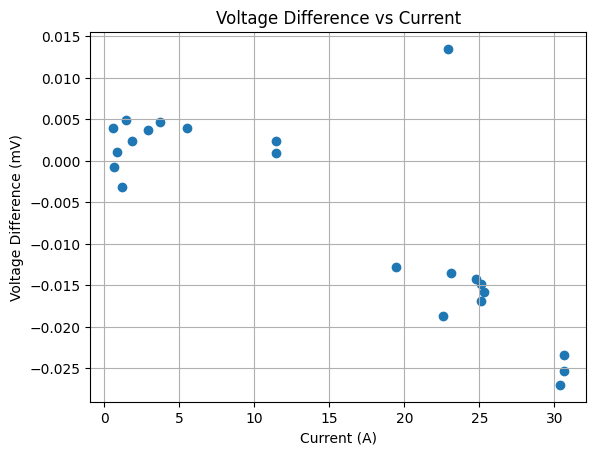

In [4]:
csv["Adjusted Voltage 1"] = csv["Voltage 1"]
csv["Adjusted Voltage 2"] = csv["Voltage 2"]
csv["Voltage Difference"] = csv["Adjusted Voltage 1"] - csv["Adjusted Voltage 2"]

print("Average Voltage difference: ", csv["Voltage Difference"].mean())

plt.scatter(csv['Current'], csv["Voltage Difference"])
plt.xlabel("Current (A)")
plt.ylabel("Voltage Difference (mV)")
plt.title("Voltage Difference vs Current")
plt.grid()

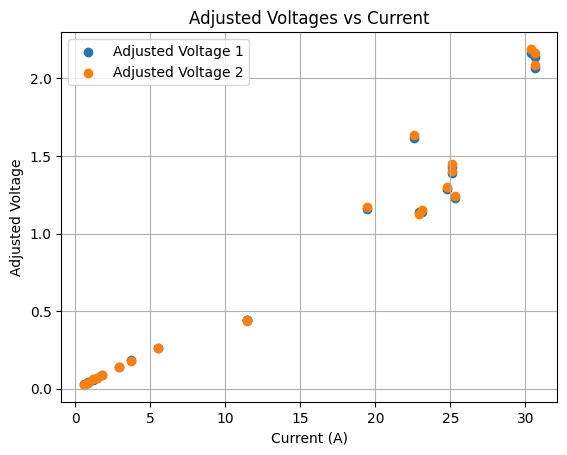

In [30]:
# Plotting 2 seperate lines for the adjusted Voltages
plt.figure()
plt.scatter(csv['Current'], csv["Adjusted Voltage 1"], label="Adjusted Voltage 1")
plt.scatter(csv['Current'], csv["Adjusted Voltage 2"], label="Adjusted Voltage 2")
plt.xlabel("Current (A)")
plt.ylabel("Adjusted Voltage")
plt.title("Adjusted Voltages vs Current")
plt.legend()
plt.grid()
plt.show()

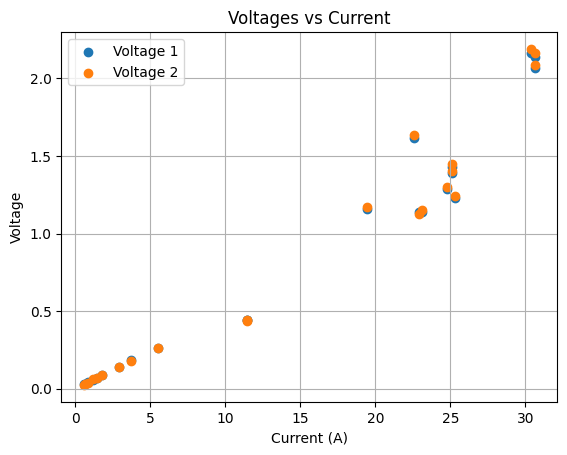

In [31]:
# Plotting 2 seperate lines for the adjusted voltages
plt.figure()
plt.scatter(csv['Current'], csv["Voltage 1"], label="Voltage 1")
plt.scatter(csv['Current'], csv["Voltage 2"], label="Voltage 2")
plt.xlabel("Current (A)")
plt.ylabel("Voltage")
plt.title("Voltages vs Current")
plt.legend()
plt.grid()
plt.show()

In [32]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func = lambda x, a, b, c: a * x**2 + b * x + c
params, _ = curve_fit.curve_fit(curve_fit_func, csv['Current'], csv['Consolidated Voltage'])
a, b, c = params
print(f"Fitted curve parameters: a={a}, b={b}, c={c}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x + {c:.8f}")
print(f"Zero current Voltage: {c:.4f} V")

#R-squared value
residuals = csv['Consolidated Voltage'] - curve_fit_func(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Voltage'] - np.mean(csv['Consolidated Voltage']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=0.001633254180723016, b=0.01571959616011598, c=0.053857293224214585
Fitted curve: y = 0.00163325 * x**2 + 0.01571960*x + 0.05385729
Zero current Voltage: 0.0539 V
R-squared value: 0.9707


In [10]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_zeroed = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_zeroed, csv['Current'], csv['Consolidated Voltage'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = csv['Consolidated Voltage'] - curve_fit_func_zeroed(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Voltage'] - np.mean(csv['Consolidated Voltage']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=0.0014233308885099054, b=0.02340159111166271
Fitted curve: y = 0.00142333 * x**2 + 0.02340159*x
Zero current Voltage: 0.0000 V
R-squared value: 0.9693


In [11]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_linear = lambda x, a, b: a * x + b
params, _ = curve_fit.curve_fit(curve_fit_func_linear, csv['Current'], csv['Consolidated Voltage'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x + {b:.8f}")
print(f"Zero current Voltage: {b:.4f} V")

#R-squared value
residuals = csv['Consolidated Voltage'] - curve_fit_func_linear(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Voltage'] - np.mean(csv['Consolidated Voltage']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=0.06339104252669879, b=-0.07988879175435831
Fitted curve: y = 0.06339104 * x + -0.07988879
Zero current Voltage: -0.0799 V
R-squared value: 0.9446


In [12]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_sigmoid = lambda x, L, k, x0: L / (1 + np.exp(-k * (x - x0)))
p0 = [30000, 0.1, 50]

params, _ = curve_fit.curve_fit(curve_fit_func_sigmoid, csv['Current'], csv['Consolidated Voltage'], p0=p0)
L, k, x0 = params
print(f"Fitted curve parameters: L={L}, k={k}, x0={x0}")
print(f"Fitted curve: y = {L:.8f} / (1 + np.exp(-{k:.8f} * (x - {x0:.8f})))")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = csv['Consolidated Voltage'] - curve_fit_func_sigmoid(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Voltage'] - np.mean(csv['Consolidated Voltage']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: L=3.872306210452554, k=0.12023510868041264, x0=29.20615491917834
Fitted curve: y = 3.87230621 / (1 + np.exp(-0.12023511 * (x - 29.20615492)))
Zero current Voltage: 0.0000 V
R-squared value: 0.9667


In [26]:
csv['Consolidated Voltage'] = (csv["Adjusted Voltage 1"] + csv["Adjusted Voltage 2"]) / 2

curve_fit_func_ended = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_ended, np.append(csv['Current'], 100), np.append(csv['Consolidated Voltage'], 5))
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current Voltage: {0:.4f} V")

#R-squared value
residuals = np.append(csv['Consolidated Voltage'] - curve_fit_func_ended(csv['Current'], *params), 5 - curve_fit_func_ended(100, *params))
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((np.append(csv['Consolidated Voltage'], 5) - np.mean(np.append(csv['Consolidated Voltage'], 5)))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=-0.0001232378890506735, b=0.06268986789356691
Fitted curve: y = -0.00012324 * x**2 + 0.06268987*x
Zero current Voltage: 0.0000 V
R-squared value: 0.9722


In [17]:
ideal_linear = lambda x: 5 / 100 * x
residual_sum_squares = np.sum((csv['Consolidated Voltage'] - ideal_linear(csv['Current']))**2)
total_sum_squares = np.sum((csv['Consolidated Voltage'] - np.mean(csv['Consolidated Voltage']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")

R-squared value: 0.8784


In [33]:
fitted_squared = lambda x: 0.00163325 * x**2 + 0.01571960*x + 0.05385729                     # R-squared: 0.9707
fitted_squared_zeroed = lambda x: 0.00142333 * x**2 + 0.02340159*x                        # R-squared: 0.9693
fitted_linear = lambda x:  0.06339104 * x + -0.07988879                                  # R-squared: 0.9446
fitted_sigmoid = lambda x: 3.87230621 / (1 + np.exp(-0.12023511 * (x - 29.20615492)))   # R-squared: 0.9667
fitted_ended = lambda x: -0.00012324 * x**2 + 0.06268987*x                                # R-squared: 0.9722
fitted_ideal_linear = lambda x: 5 / 100 * x                                     # R-squared: 0.8784

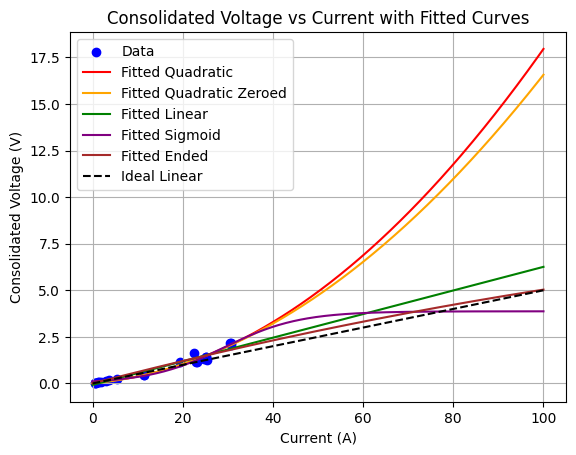

In [34]:
plt.scatter(csv['Current'], csv['Consolidated Voltage'], label="Data", color='blue')

x_values = np.linspace(0, 100, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Current (A)")
plt.ylabel("Consolidated Voltage (V)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()

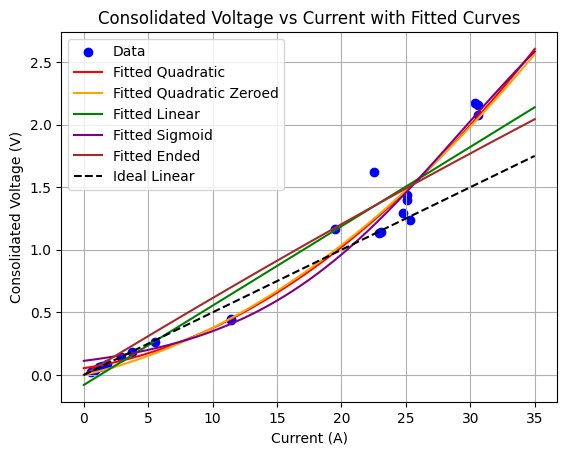

In [37]:
plt.scatter(csv['Current'], csv['Consolidated Voltage'], label="Data", color='blue')

x_values = np.linspace(0, 35, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Current (A)")
plt.ylabel("Consolidated Voltage (V)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()

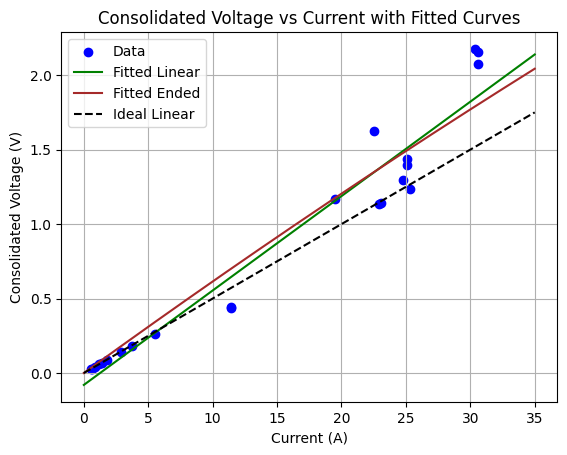

In [39]:
# Shortlisted
# fitted_linear = lambda x:  0.06339104 * x + -0.07988879                                  # R-squared: 0.9446
# fitted_ended = lambda x: -0.00012324 * x**2 + 0.06268987*x                                # R-squared: 0.9722

plt.scatter(csv['Current'], csv['Consolidated Voltage'], label="Data", color='blue')

x_values = np.linspace(0, 35, 500)
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Current (A)")
plt.ylabel("Consolidated Voltage (V)")
plt.title("Consolidated Voltage vs Current with Fitted Curves")
plt.legend()
plt.grid()